In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv('train.csv', usecols=['Age', 'Fare', 'Survived'])
df.sample(5)

,Survived,Age,Fare
286,1,30.0,9.5000
77,0,NaN,8.0500
308,0,30.0,24.0000
175,0,18.0,7.8542
722,0,34.0,13.0000


In [3]:
df.isnull().mean()*100

Survived     0.00000
Age         19.86532
Fare         0.00000
dtype: float64

In [4]:
x= df.drop(columns=['Survived'])
y = df['Survived']

In [5]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)

In [6]:
x_train['Age_imputed'] = x_train['Age'].copy()
x_test['Age_imputed'] = x_test['Age'].copy()

In [7]:
x_train.loc[x_train['Age_imputed'].isnull(), 'Age_imputed'] = x_train['Age'].dropna().sample(x_train['Age_imputed'].isnull().sum()).values

x_test.loc[x_test['Age_imputed'].isnull(), 'Age_imputed'] = x_train['Age'].dropna().sample(x_test['Age_imputed'].isnull().sum()).values

In [8]:
x_train['Age'].isnull().sum()

np.int64(140)

In [9]:
x_train

,Age,Fare,Age_imputed
331,45.5,28.5000,45.5
733,23.0,13.0000,23.0
382,32.0,7.9250,32.0
704,26.0,7.8542,26.0
813,6.0,31.2750,6.0
...,...,...,...
106,21.0,7.6500,21.0
270,NaN,31.0000,19.0
860,41.0,14.1083,41.0
435,14.0,120.0000,14.0


C:\Users\bhavy\AppData\Local\Temp\ipykernel_20660\4096331500.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train['Age'],label='Original', hist=False)
C:\Users\bhavy\AppData\Local\Temp\ipykernel_20660\4096331500.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train

<Axes: xlabel='Age_imputed', ylabel='Density'>

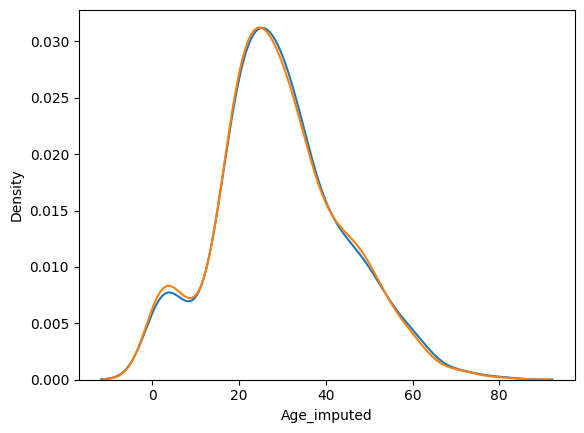

In [10]:
sns.distplot(x_train['Age'],label='Original', hist=False)
sns.distplot(x_train['Age_imputed'],label='Imputed', hist=False)

In [11]:
x_train['Age_imputed'].var()

np.float64(210.40274496357404)

In [12]:
x_train['Age'].var()

np.float64(210.2517072477435)

In [13]:
x_train[['Fare','Age','Age_imputed']].cov()

,Fare,Age,Age_imputed
Fare,2700.831981,71.580633,62.400605
Age,71.580633,210.251707,210.251707
Age_imputed,62.400605,210.251707,210.402745


<Axes: >

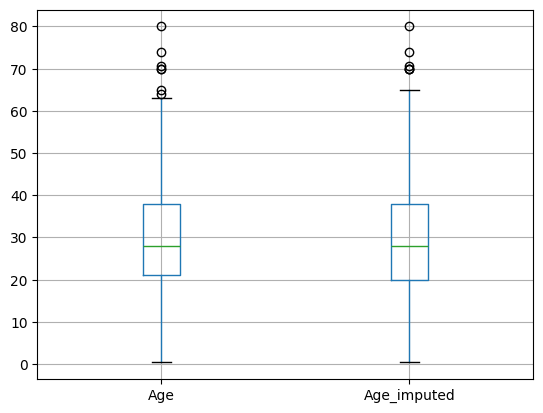

In [14]:
x_train[['Age', 'Age_imputed']].boxplot()

### now for catogorical data

In [15]:
data = pd.read_csv('house-train.csv', usecols=['GarageQual','FireplaceQu', 'SalePrice'])

In [16]:
data.sample(5)

,FireplaceQu,GarageQual,SalePrice
1259,NaN,TA,151000
465,TA,TA,178740
1170,Po,TA,171000
70,Gd,TA,244000
238,NaN,TA,318000


In [17]:
data.describe()

,SalePrice
count,1460.000000
mean,180921.195890
std,79442.502883
min,34900.000000
25%,129975.000000
50%,163000.000000
75%,214000.000000
max,755000.000000


In [18]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   FireplaceQu  770 non-null    str  
 1   GarageQual   1379 non-null   str  
 2   SalePrice    1460 non-null   int64
dtypes: int64(1), str(2)
memory usage: 34.3 KB


In [19]:
data.isnull().mean()*100

FireplaceQu    47.260274
GarageQual      5.547945
SalePrice       0.000000
dtype: float64

In [20]:
x = data
y = data['SalePrice']

In [21]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)

In [22]:
x_train['GarageQual_imputed'] = x_train['GarageQual'].copy()
x_train['FireplaceQu_imputed'] = x_train['FireplaceQu'].copy()

x_test['GarageQual_imputed'] = x_test['GarageQual'].copy()
x_test['FireplaceQu_imputed'] = x_test['FireplaceQu'].copy()

In [23]:
x_train.loc[x_train['GarageQual_imputed'].isnull(), 'GarageQual_imputed'] = x_train['GarageQual'].dropna().sample(x_train['GarageQual_imputed'].isnull().sum()).values

x_test.loc[x_test['FireplaceQu_imputed'].isnull(), 'FireplaceQu_imputed'] = x_train['FireplaceQu'].dropna().sample(x_test['FireplaceQu_imputed'].isnull().sum()).values

In [26]:
temp = pd.concat([
    x_train['GarageQual'].value_counts() / len(x_train['GarageQual'].dropna()),
    x_train['GarageQual_imputed'].value_counts() / len(x_train)
], axis=1)

temp.columns =['Original', 'Imputed']

In [27]:
temp

,Original,Imputed
TA,0.951087,0.951199
Fa,0.032609,0.033390
Gd,0.011775,0.011130
Ex,0.002717,0.002568
Po,0.001812,0.001712


In [32]:
# its a red falhg bcz of the heavy deviation
temp_fire = pd.concat([
    x_train['FireplaceQu'].value_counts() / len(x_train['FireplaceQu'].dropna()),
    x_train['FireplaceQu_imputed'].value_counts() / len(x_train)
], axis=1)
temp_fire.columns = ['Original', 'Imputed']

In [33]:
temp_fire

,Original,Imputed
Gd,0.491143,0.261130
TA,0.405797,0.215753
Fa,0.043478,0.023116
Ex,0.033816,0.017979
Po,0.025765,0.013699


C:\Users\bhavy\AppData\Local\Temp\ipykernel_20660\2578983325.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train[x_train['FireplaceQu'] == category]['SalePrice'],hist=False,label=category)
C:\Users\bhavy\AppData\Local\Temp\ipykernel_20660\2578983325.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457a

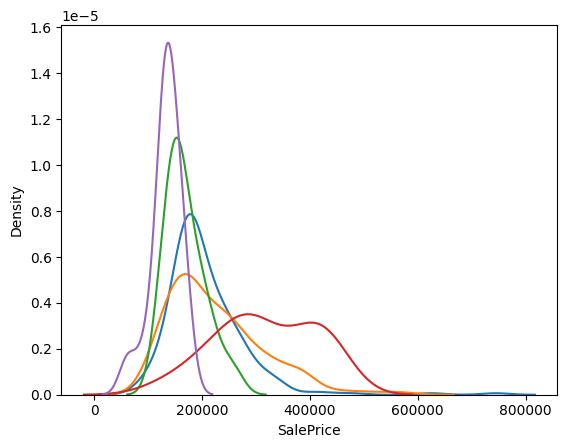

In [35]:
for category in x_train['FireplaceQu'].dropna().unique():
    sns.distplot(x_train[x_train['FireplaceQu'] == category]['SalePrice'],hist=False,label=category)
plt.show()

C:\Users\bhavy\AppData\Local\Temp\ipykernel_20660\484091634.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train[x_train['FireplaceQu_imputed'] == category]['SalePrice'],hist=False,label=category)
C:\Users\bhavy\AppData\Local\Temp\ipykernel_20660\484091634.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed29

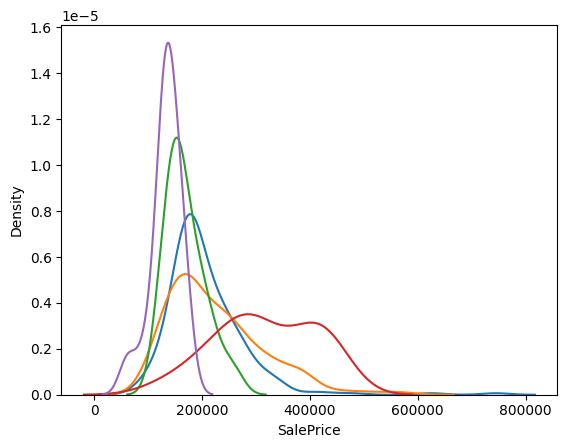

In [36]:
for category in x_train['FireplaceQu_imputed'].dropna().unique():
    sns.distplot(x_train[x_train['FireplaceQu_imputed'] == category]['SalePrice'],hist=False,label=category)
plt.show()